## Project description

This analysis examines historical crop yield data (1990 -2013) for ten major staple crops across global producing countries. The study integrates crop-yield statististics from FAO with pesticide usage(FAO) and rainfall data (World bank) to identify temporal trends, region differences, and potential environmental drivers of crop yield variations.


**The crops analyzed include:**

- Cassava
- Maize
- Potatoes
- Rice (paddy)
- Sorghum
- Soybeans
- Sweet potatoes
- Wheat 
- Yams
- Plantains and others.

**Data:**

The data used in this project was sourced from the FAO website(crop yields,and pesticides), and the World data Bank (rainfall)



## Gathering and cleaning the data

In [1]:
import pandas as pd
from src.data_inspection import DataInspector, DatatypesInspection,SummaryStatistics
from src.missing_values import SimpleMissingValuesAnalysis, MissingValuesAnalysis

------------------------------------------------------------------------------------------

## **Crop Yield Data**

Upon a brief inspection, the dataset comprises ten of the most consumed crops around the world. The dataset includes country, item (crop), year (starting from 1961 to 2016), and the yield value.

In [2]:
data_path = "../data/raw/yield.csv"
df_yield= pd.read_csv(data_path)
df_yield.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


**Understanding the dataset at a glance**

In [3]:
inspector = DataInspector(DatatypesInspection())
inspector.execute_inspection(df_yield)


Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB
None


In [4]:
inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df_yield)


Summary statistics (Numerical features):
          Area Code  Element Code     Item Code     Year Code          Year  \
count  56717.000000       56717.0  56717.000000  56717.000000  56717.000000   
mean     125.650422        5419.0    111.611651   1989.669570   1989.669570   
std       75.120195           0.0    101.278435     16.133198     16.133198   
min        1.000000        5419.0     15.000000   1961.000000   1961.000000   
25%       58.000000        5419.0     56.000000   1976.000000   1976.000000   
50%      122.000000        5419.0    116.000000   1991.000000   1991.000000   
75%      184.000000        5419.0    125.000000   2004.000000   2004.000000   
max      351.000000        5419.0    489.000000   2016.000000   2016.000000   

                Value  
count    56717.000000  
mean     62094.660084  
std      67835.932856  
min          0.000000  
25%      15680.000000  
50%      36744.000000  
75%      86213.000000  
max    1000000.000000  

Data shape:  (56717, 12)

Sum

In [5]:
df_yield['Item'].unique()

array(['Maize', 'Potatoes', 'Rice, paddy', 'Wheat', 'Sorghum', 'Soybeans',
       'Cassava', 'Yams', 'Sweet potatoes', 'Plantains and others'],
      dtype=object)

**Missing values**


Missing values by column:
Series([], dtype: int64)


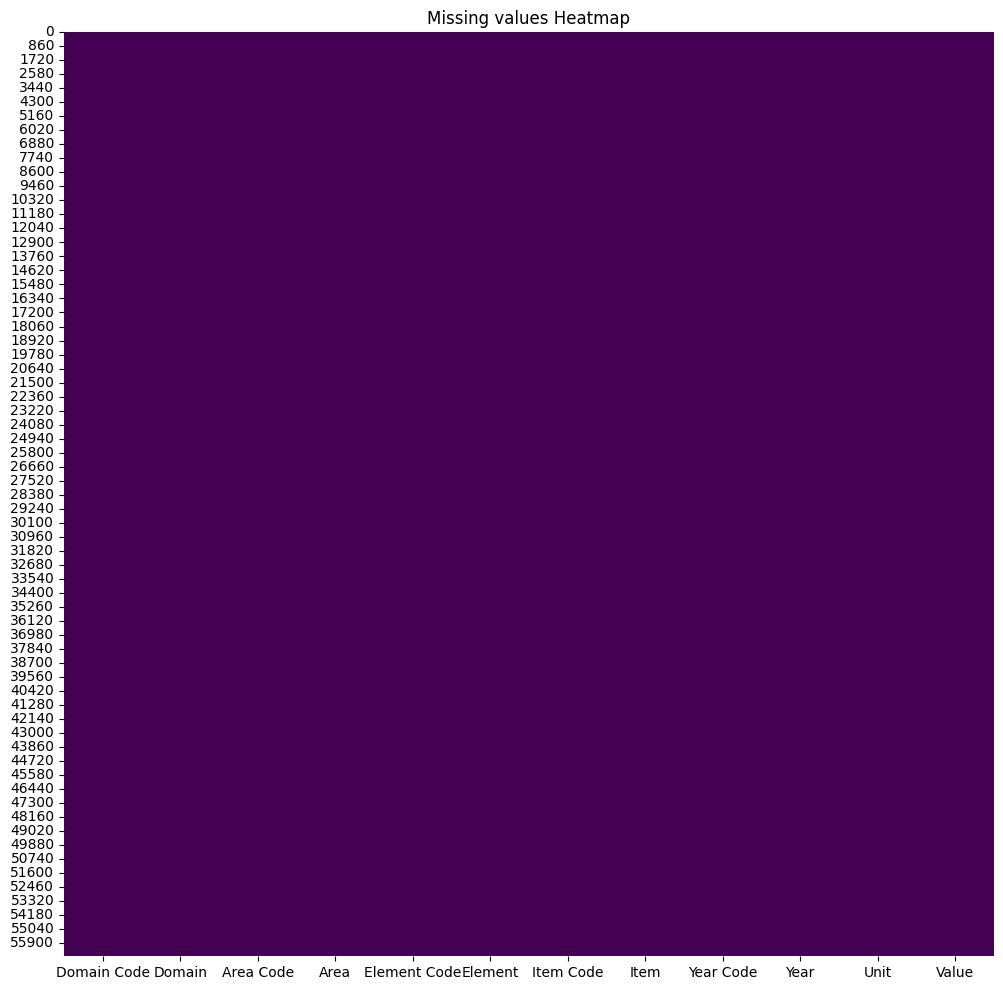

In [6]:
analyze_missing_values =SimpleMissingValuesAnalysis()
analyze_missing_values.analyze(df_yield)

***Current insights***

The bits in yellow are meant to depict missing values. Those in purple hold tangible data.

Fortunately, we only have tangible data.

There are over 56,000 entries for this dataset, a farely large sample size.

The data colllated dates as far back as 1961 up until 2016


**The dataset contains 10 crop types**
- Maize
- Potatoes
- Rice Paddy
- Wheat
- Sorghum
- Soybeans
- Cassava
- Yams
- Sweet Potatoes
- Plantains and others


We have both categorical and numerical data here. But before analysing either of them, we'll drop the unnecessary columns

***Columns that might prove unuseful for analysis:***

- Domain Code: It is the same across the rows (QC)
- Domain: It is also the same across the rows (Crops)
- Area code: It's like an Id for each area in the dataset, we can work alone with the area column
- Element code: It's redundant too, every row contains the same value 5419
- Element: Redundant, only value there is Yield.
- Item code: Only serves as an id for each item, not much analytical value there, we can work with the Item column instead
- Year code: Appears to be the same as the Year itself. A redundant column
- Unit: Tells us that each unit of crop is in hg/ha. Will be useful for understanding the quantity we're truly working with, but not much use for the column.



In [7]:
df_yield = df_yield.drop(['Domain Code','Domain','Area Code','Element Code','Element','Item Code','Year Code','Unit'], axis = 1)
df_yield = df_yield.rename(index= str, columns={'Value':"crop_yields"})
df_yield.head()

,Area,Item,Year,crop_yields
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400


------------------------------------------

## **RainFall**

Climate factors like rainfall, and temperature largely contribute to the crop yields each year. The information gathered from the World Bank would prove useful, as it contains the average rainfall per year for each country.

The dataset includes entries for Area(country), Year, and the average rainfall in millimeters.

In [8]:
df_rain = pd.read_csv('../data/raw/rainfall.csv')
df_rain.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


**Understanding the dataset**

In [9]:
inspector = DataInspector(DatatypesInspection())
inspector.execute_inspection(df_rain)


Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Area                           6727 non-null   object
 1   Year                           6727 non-null   int64 
 2   average_rain_fall_mm_per_year  5953 non-null   object
dtypes: int64(1), object(2)
memory usage: 157.8+ KB
None


In [10]:
inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df_rain)


Summary statistics (Numerical features):
              Year
count  6727.000000
mean   2001.354839
std       9.530114
min    1985.000000
25%    1993.000000
50%    2001.000000
75%    2010.000000
max    2017.000000

Data shape:  (6727, 3)

Summary statistics (Categorical features):
               Area average_rain_fall_mm_per_year
count          6727                          5953
unique          217                           173
top     Afghanistan                          1010
freq             31                            62


**Missing Values**


Missing values by column:
average_rain_fall_mm_per_year    774
dtype: int64


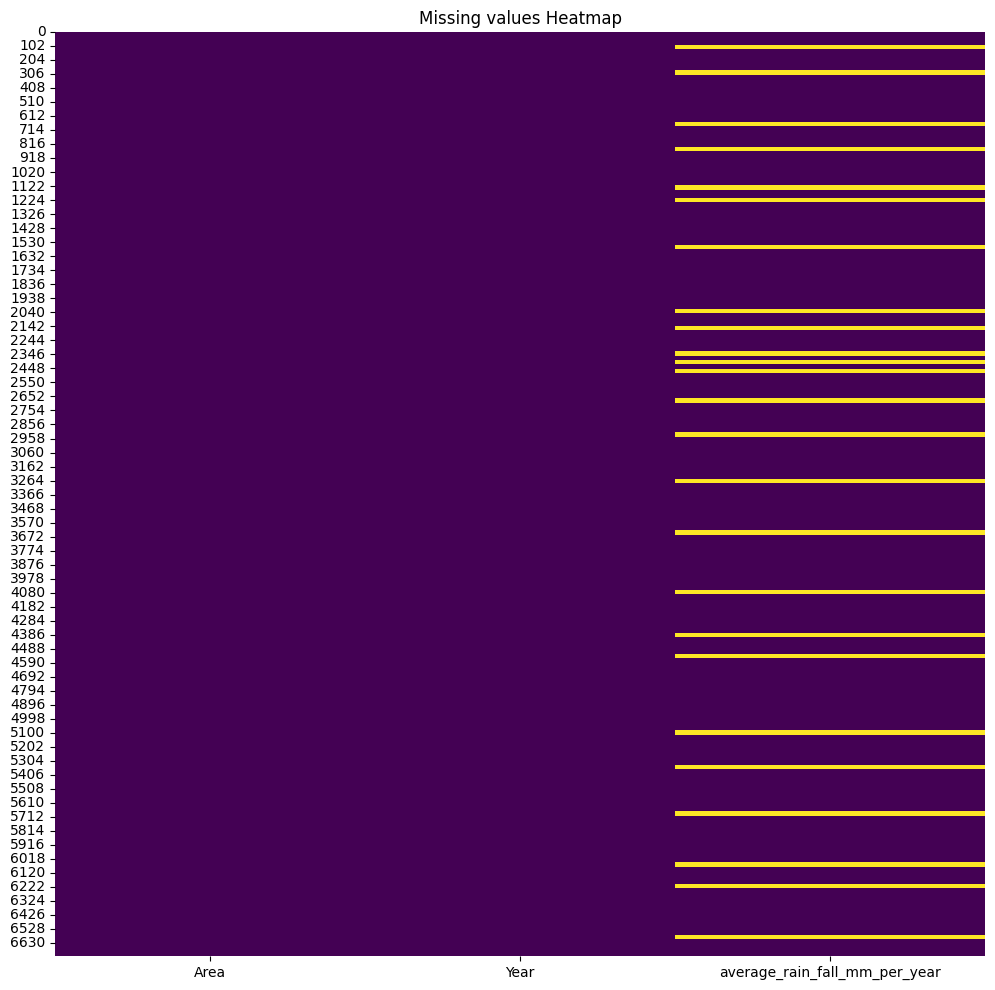

In [11]:
analyze_missing_values.analyze(df_rain)

There are some missing values in this dataset, only in the 'average_rain_fall_mm_per_year' column. Not as much as the tangible ones, it's safe to drop them.

In [12]:
# Data is currently object type, convert to float
df_rain['average_rain_fall_mm_per_year'] = pd.to_numeric(df_rain['average_rain_fall_mm_per_year'], errors = 'coerce')
print("Current data types\n")
df_rain.info()

Current data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           6727 non-null   object 
 1   Year                           6727 non-null   int64  
 2   average_rain_fall_mm_per_year  5947 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 157.8+ KB


In [13]:
from src.handle_missing_values import MissingValueHandler, FillMissingValuesStrat, DropMissingvaluesStrat

handler = MissingValueHandler(DropMissingvaluesStrat())
df_rain = handler.execute_strategy(df_rain)

2026-03-19 07:40:27,276 - INFO - Executing missing value handling strategy.
2026-03-19 07:40:27,278 - INFO - Dropping missing values with axis = 0 and threshold = None
2026-03-19 07:40:27,282 - INFO - Missing values dropped.



Missing values by column:
Series([], dtype: int64)


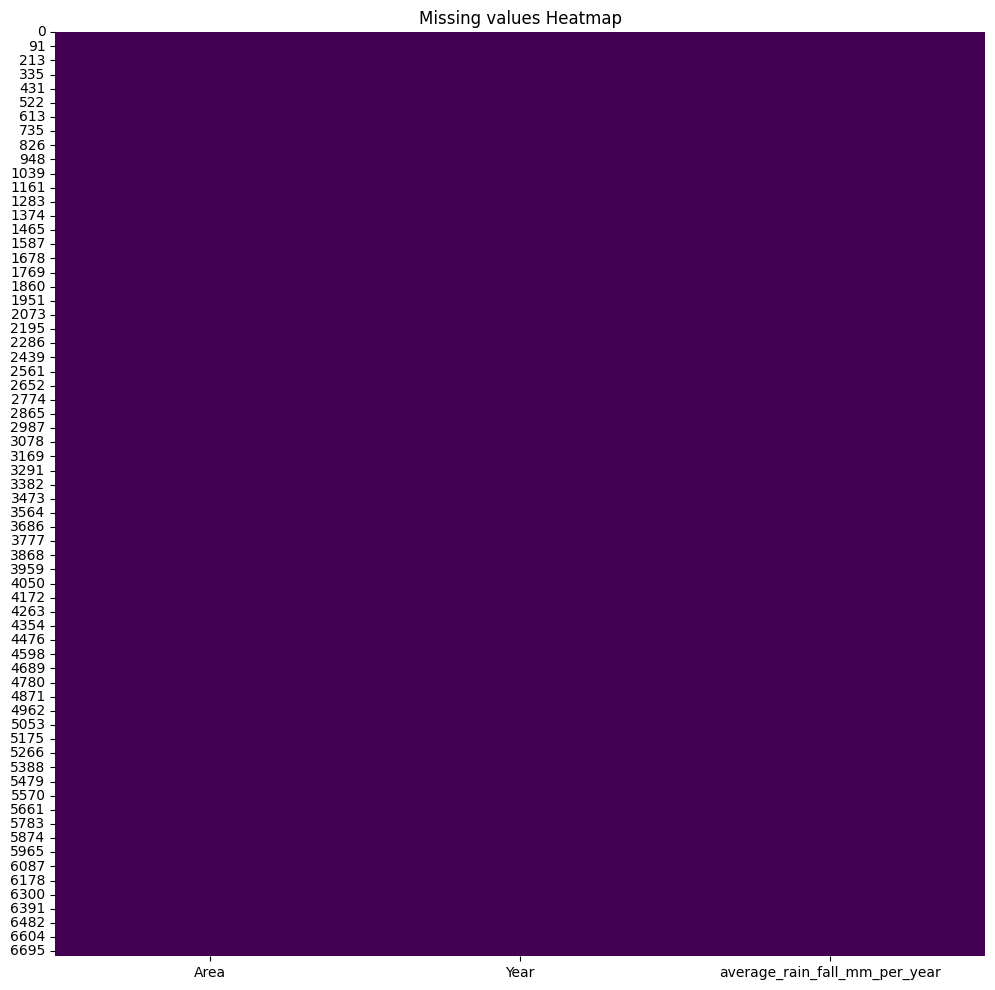

In [14]:
analyze_missing_values.analyze(df_rain)

Now that we're in the all clear. We can attempt to describe the average rainfall per year

In [15]:
df_rain.describe()

,Year,average_rain_fall_mm_per_year
count,5947.000000,5947.000000
mean,2001.365899,1124.743232
std,9.526335,786.257365
min,1985.000000,51.000000
25%,1993.000000,534.000000
50%,2001.000000,1010.000000
75%,2010.000000,1651.000000
max,2017.000000,3240.000000


***Current insights***

Over 6,700 rainfall data was collated for this dataset.

It was collated from 1985 up until 2017.
The least average rain fall captured was as low as 51 mm.
It's an easy assumption that it would drastically affect the crop yield in that year. 


**Merging the rainfall and crop yields dataset on the year and area columns**

In [16]:
df = pd.merge(df_rain,df_yield, on = ['Year', 'Area'])

In [17]:
df.head()

,Area,Year,average_rain_fall_mm_per_year,Item,crop_yields
0,Afghanistan,1985,327.0,Maize,16652
1,Afghanistan,1985,327.0,Potatoes,140909
2,Afghanistan,1985,327.0,"Rice, paddy",22482
3,Afghanistan,1985,327.0,Wheat,12277
4,Afghanistan,1986,327.0,Maize,16875


In [18]:
inspector.execute_inspection(df)


Summary statistics (Numerical features):
               Year  average_rain_fall_mm_per_year    crop_yields
count  25385.000000                   25385.000000   25385.000000
mean    2001.278787                    1254.849754   68312.278353
std        9.143915                     804.449430   75213.292733
min     1985.000000                      51.000000      50.000000
25%     1994.000000                     630.000000   17432.000000
50%     2001.000000                    1150.000000   38750.000000
75%     2009.000000                    1761.000000   94286.000000
max     2016.000000                    3240.000000  554855.000000

Data shape:  (25385, 5)

Summary statistics (Categorical features):
            Area   Item
count      25385  25385
unique       161     10
top     Cameroon  Maize
freq         300   3980


In [19]:
inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df)


Summary statistics (Numerical features):
               Year  average_rain_fall_mm_per_year    crop_yields
count  25385.000000                   25385.000000   25385.000000
mean    2001.278787                    1254.849754   68312.278353
std        9.143915                     804.449430   75213.292733
min     1985.000000                      51.000000      50.000000
25%     1994.000000                     630.000000   17432.000000
50%     2001.000000                    1150.000000   38750.000000
75%     2009.000000                    1761.000000   94286.000000
max     2016.000000                    3240.000000  554855.000000

Data shape:  (25385, 5)

Summary statistics (Categorical features):
            Area   Item
count      25385  25385
unique       161     10
top     Cameroon  Maize
freq         300   3980


***Current Insights***

Merging with Area and Year produces 25,385 columns out of over 63,000 collective columns.


The data we collated now starts from 1985, that's as early as the rainfall data begins.


------------------------------------------

## **Pesticide**

In [20]:
df_pesticide = pd.read_csv('../data/raw/pesticides.csv')
df_pesticide.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


**Understanding the dataset**

In [21]:
inspector.set_strategy(DatatypesInspection())
inspector.execute_inspection(df_pesticide)


Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   object 
 1   Area     4349 non-null   object 
 2   Element  4349 non-null   object 
 3   Item     4349 non-null   object 
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   object 
 6   Value    4349 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 238.0+ KB
None


In [22]:
inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df_pesticide)


Summary statistics (Numerical features):
              Year         Value
count  4349.000000  4.349000e+03
mean   2003.138883  2.030334e+04
std       7.728044  1.177362e+05
min    1990.000000  0.000000e+00
25%    1996.000000  9.300000e+01
50%    2003.000000  1.137560e+03
75%    2010.000000  7.869000e+03
max    2016.000000  1.807000e+06

Data shape:  (4349, 7)

Summary statistics (Categorical features):
                Domain     Area Element                Item  \
count             4349     4349    4349                4349   
unique               1      168       1                   1   
top     Pesticides Use  Albania     Use  Pesticides (total)   
freq              4349       27    4349                4349   

                                Unit  
count                           4349  
unique                             1  
top     tonnes of active ingredients  
freq                            4349  


In [23]:
for col in df_pesticide.columns:
    print("Column: ", col)
    print("-------------------------------")
    print(df_pesticide[col].unique(),"\n")
    

Column:  Domain
-------------------------------
['Pesticides Use'] 

Column:  Area
-------------------------------
['Albania' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belgium-Luxembourg' 'Belize' 'Bermuda'
 'Bhutan' 'Bolivia (Plurinational State of)' 'Botswana' 'Brazil'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cameroon' 'Canada' 'Central African Republic' 'Chad' 'Chile'
 'China, Hong Kong SAR' 'China, Macao SAR' 'China, mainland'
 'China, Taiwan Province of' 'Colombia' 'Comoros' 'Congo' 'Cook Islands'
 'Costa Rica' "Côte d'Ivoire" 'Croatia' 'Cyprus' 'Czechia' 'Denmark'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea' 'Estonia'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'French Polynesia' 'Gambia'
 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indone

***Current Insights***

The pesticide data was collated from 1990 up until 2016. 

There's 4349 entries grouped in 7 columns: Domain, Area, Element, Item, Year, Unit, and Value.

Columns Element, Domain, Unit and Item are redundant. The data across the columns are the same.

In [24]:
df_pesticide = df_pesticide.drop(['Element','Domain', 'Unit', 'Item'], axis = 1)

In [25]:
df_pesticide.head()

,Area,Year,Value
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


In [26]:
# Now joining the pesticide data with the rain and crop yields dataset

# But first renaming the Value column in df_pesticide, to avoid misunderstandings with the Value already in df
df_pesticide = df_pesticide.rename(index=str, columns={'Value':"pesticide_tonnes"})

df_pesticide.head()


,Area,Year,pesticide_tonnes
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


**Final check:** Checking for missing data


Missing values by column:
Series([], dtype: int64)


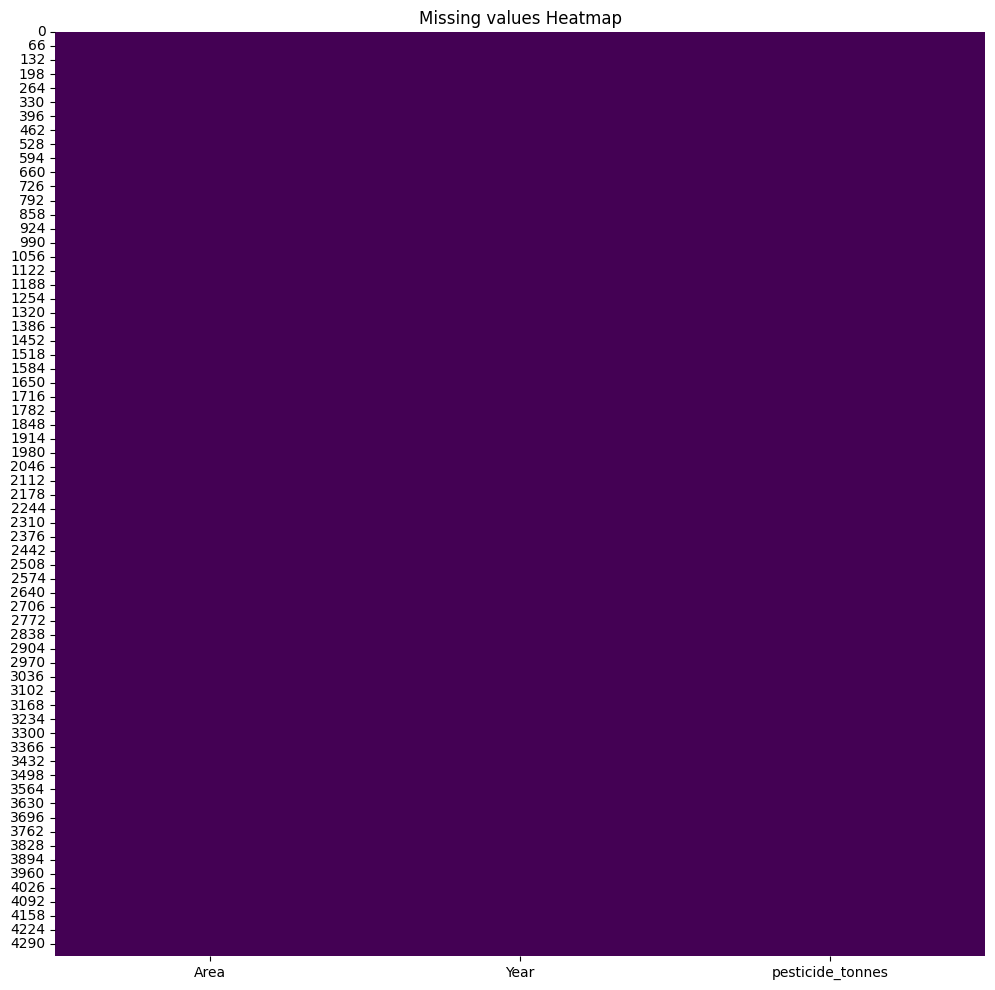

In [27]:
analyze_missing_values.analyze(df_pesticide)

There's fortunately no missing values, it's safe for merging:

In [28]:
# Merging the pesticide_tonnes column from df_pesticide with df

df = pd.merge(df, df_pesticide, on =['Year', 'Area'])

In [29]:
df.head()

,Area,Year,average_rain_fall_mm_per_year,Item,crop_yields,pesticide_tonnes
0,Albania,1990,1485.0,Maize,36613,121.0
1,Albania,1990,1485.0,Potatoes,66667,121.0
2,Albania,1990,1485.0,"Rice, paddy",23333,121.0
3,Albania,1990,1485.0,Sorghum,12500,121.0
4,Albania,1990,1485.0,Soybeans,7000,121.0


In [30]:
# Quick analysis for df

inspector.set_strategy(DatatypesInspection())
inspector.execute_inspection(df)

inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df)


Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18949 entries, 0 to 18948
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           18949 non-null  object 
 1   Year                           18949 non-null  int64  
 2   average_rain_fall_mm_per_year  18949 non-null  float64
 3   Item                           18949 non-null  object 
 4   crop_yields                    18949 non-null  int64  
 5   pesticide_tonnes               18949 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 888.4+ KB
None

Summary statistics (Numerical features):
               Year  average_rain_fall_mm_per_year    crop_yields  \
count  18949.000000                   18949.000000   18949.000000   
mean    2003.216001                    1204.523722   71857.501821   
std        7.895764                     784.739435   79684.570

Data seems fine, safe to proceed.

-----------------------

## **Temperature**

The average temperature for each country was resourced from the world bank. The data here was collated from 1743 to 2013.

It contains a year, country and avg_temp column.

In [31]:
df_temp =pd.read_csv('../data/raw/temp.csv')
df_temp.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [32]:
inspector.set_strategy(DatatypesInspection())
inspector.execute_inspection(df_temp)


Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71311 entries, 0 to 71310
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      71311 non-null  int64  
 1   country   71311 non-null  object 
 2   avg_temp  68764 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ MB
None


There's obviously some null data in avg_temp, it doesn't add up to the amount on year and country

In [33]:
inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df_temp)


Summary statistics (Numerical features):
               year      avg_temp
count  71311.000000  68764.000000
mean    1905.799007     16.183876
std       67.102099      7.592960
min     1743.000000    -14.350000
25%     1858.000000      9.750000
50%     1910.000000     16.140000
75%     1962.000000     23.762500
max     2013.000000     30.730000

Data shape:  (71311, 3)

Summary statistics (Categorical features):
              country
count           71311
unique            137
top     United States
freq            11973


***Current insights***

The data here starts from 1743 to 2013. Average temperature recorded ranges from as low as -14.35 to 30.73.

Dropping the empty columns we spotted earlier:


In [34]:
df_temp = df_temp.dropna()

In [35]:
df_temp.isna().sum()

year        0
country     0
avg_temp    0
dtype: int64

Merging with the df dataframe

In [36]:
df_temp = df_temp.rename(index= str, columns ={"year":'Year', 'country':'Area'})
df = pd.merge(df, df_temp, on =['Year', 'Area'])

df.head()


,Area,Year,average_rain_fall_mm_per_year,Item,crop_yields,pesticide_tonnes,avg_temp
0,Albania,1990,1485.0,Maize,36613,121.0,16.37
1,Albania,1990,1485.0,Potatoes,66667,121.0,16.37
2,Albania,1990,1485.0,"Rice, paddy",23333,121.0,16.37
3,Albania,1990,1485.0,Sorghum,12500,121.0,16.37
4,Albania,1990,1485.0,Soybeans,7000,121.0,16.37


In [37]:
df.describe()

,Year,average_rain_fall_mm_per_year,crop_yields,pesticide_tonnes,avg_temp
count,28242.000000,28242.00000,28242.000000,28242.000000,28242.000000
mean,2001.544296,1149.05598,77053.332094,37076.909344,20.542627
std,7.051905,709.81215,84956.612897,59958.784665,6.312051
min,1990.000000,51.00000,50.000000,0.040000,1.300000
25%,1995.000000,593.00000,19919.250000,1702.000000,16.702500
50%,2001.000000,1083.00000,38295.000000,17529.440000,21.510000
75%,2008.000000,1668.00000,104676.750000,48687.880000,26.000000
max,2013.000000,3240.00000,501412.000000,367778.000000,30.650000


In [38]:
df.isnull().sum()

Area                             0
Year                             0
average_rain_fall_mm_per_year    0
Item                             0
crop_yields                      0
pesticide_tonnes                 0
avg_temp                         0
dtype: int64

So, no null data hidden here.

The data as expected wouldn't start from 1743, but it instead starts from 1990, it previously started from 1985, perhaps there is not sufficient data for that time period on corresponding locations in the temperature dataset

--------------------------------------

## **Analyzing the data**

In [39]:
df.head()

,Area,Year,average_rain_fall_mm_per_year,Item,crop_yields,pesticide_tonnes,avg_temp
0,Albania,1990,1485.0,Maize,36613,121.0,16.37
1,Albania,1990,1485.0,Potatoes,66667,121.0,16.37
2,Albania,1990,1485.0,"Rice, paddy",23333,121.0,16.37
3,Albania,1990,1485.0,Sorghum,12500,121.0,16.37
4,Albania,1990,1485.0,Soybeans,7000,121.0,16.37


In [40]:
inspector.set_strategy(DatatypesInspection())
inspector.execute_inspection(df)



Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Year                           28242 non-null  int64  
 2   average_rain_fall_mm_per_year  28242 non-null  float64
 3   Item                           28242 non-null  object 
 4   crop_yields                    28242 non-null  int64  
 5   pesticide_tonnes               28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB
None


In [41]:
inspector.set_strategy(SummaryStatistics())
inspector.execute_inspection(df)


Summary statistics (Numerical features):
               Year  average_rain_fall_mm_per_year    crop_yields  \
count  28242.000000                    28242.00000   28242.000000   
mean    2001.544296                     1149.05598   77053.332094   
std        7.051905                      709.81215   84956.612897   
min     1990.000000                       51.00000      50.000000   
25%     1995.000000                      593.00000   19919.250000   
50%     2001.000000                     1083.00000   38295.000000   
75%     2008.000000                     1668.00000  104676.750000   
max     2013.000000                     3240.00000  501412.000000   

       pesticide_tonnes      avg_temp  
count      28242.000000  28242.000000  
mean       37076.909344     20.542627  
std        59958.784665      6.312051  
min            0.040000      1.300000  
25%         1702.000000     16.702500  
50%        17529.440000     21.510000  
75%        48687.880000     26.000000  
max       367778

**Univariate Analysis**

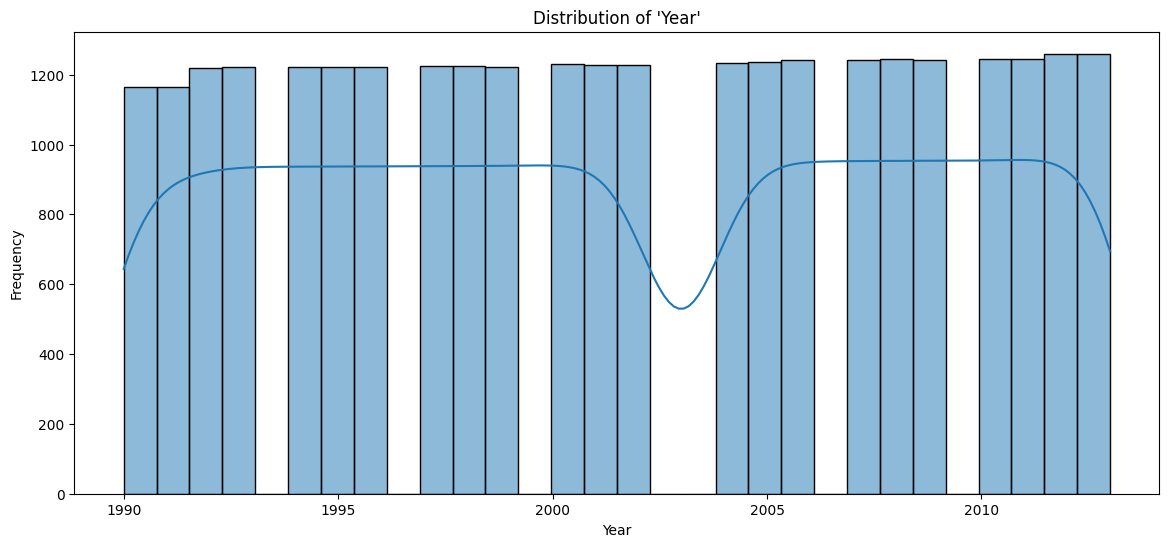

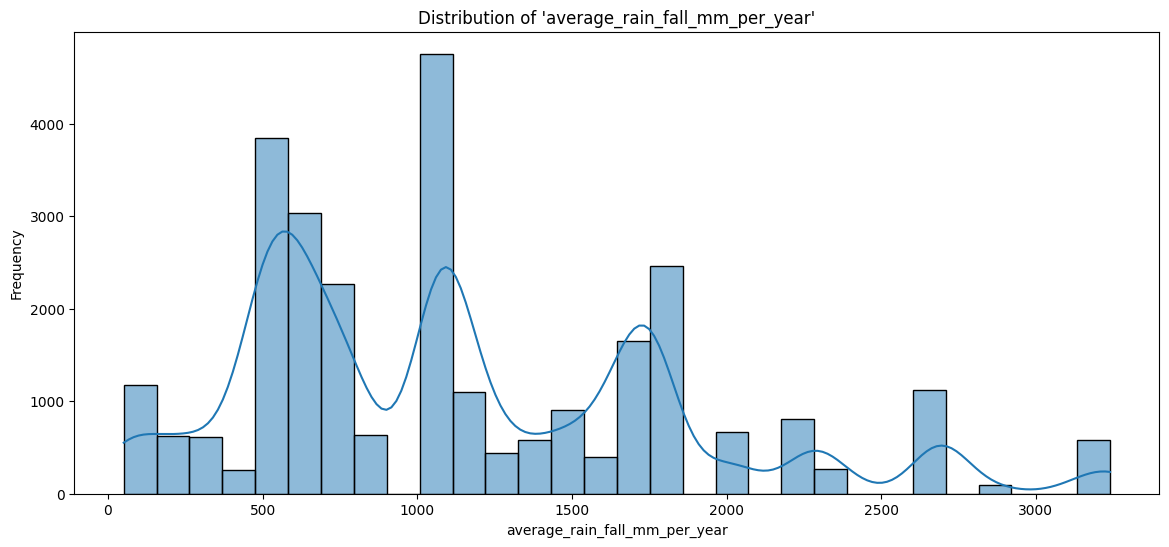

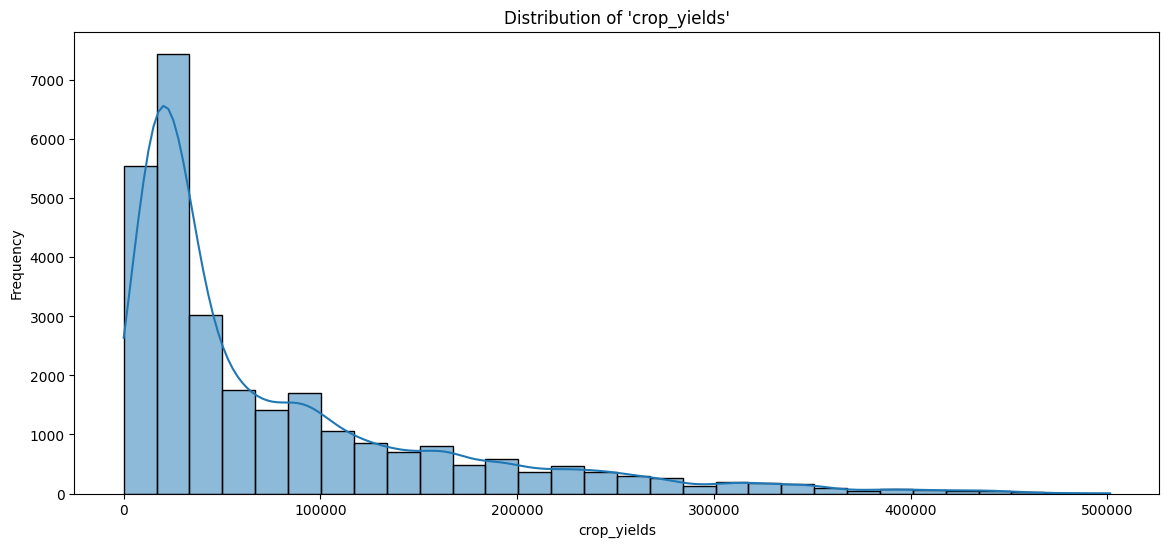

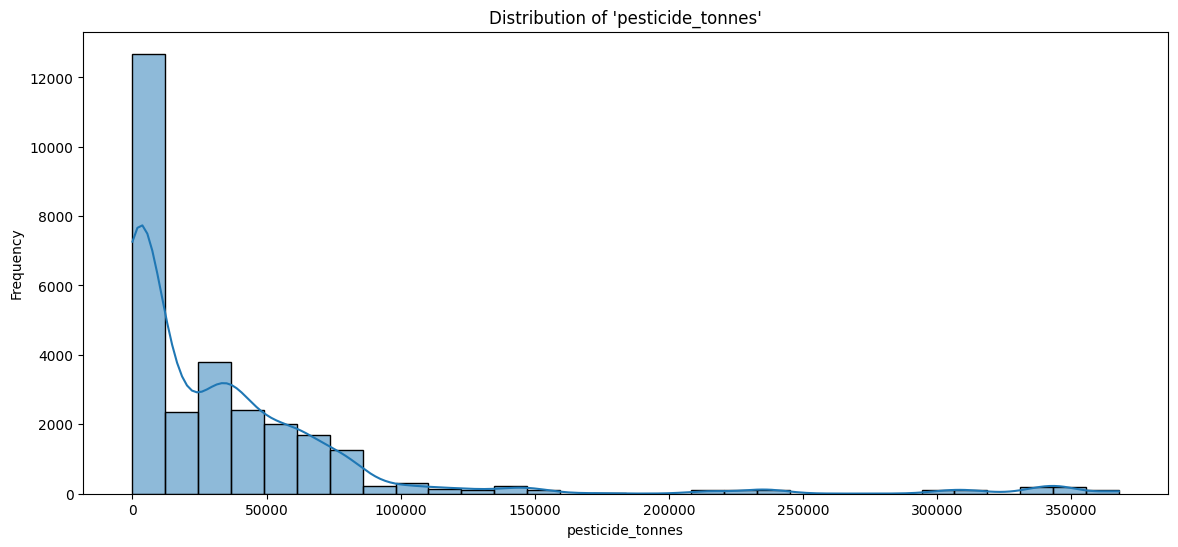

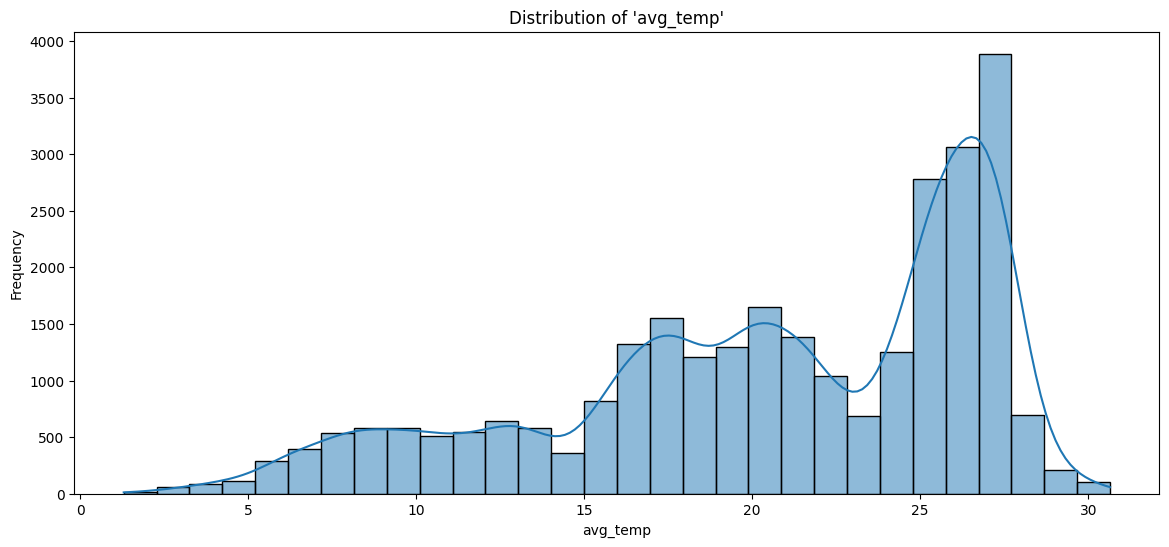

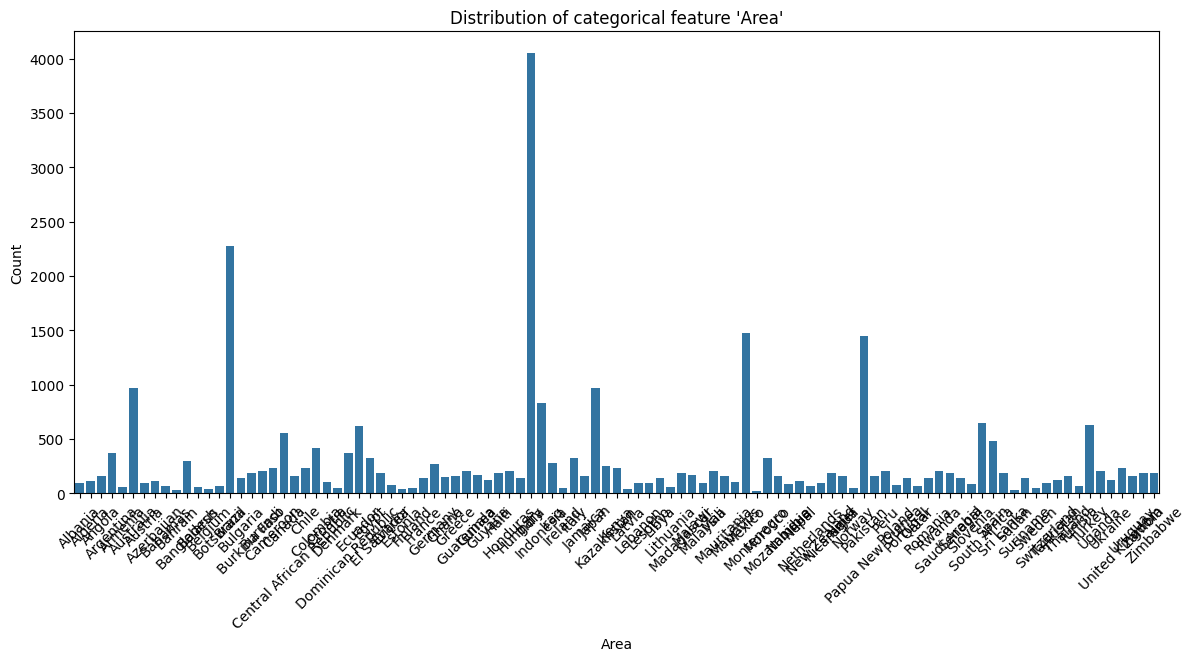

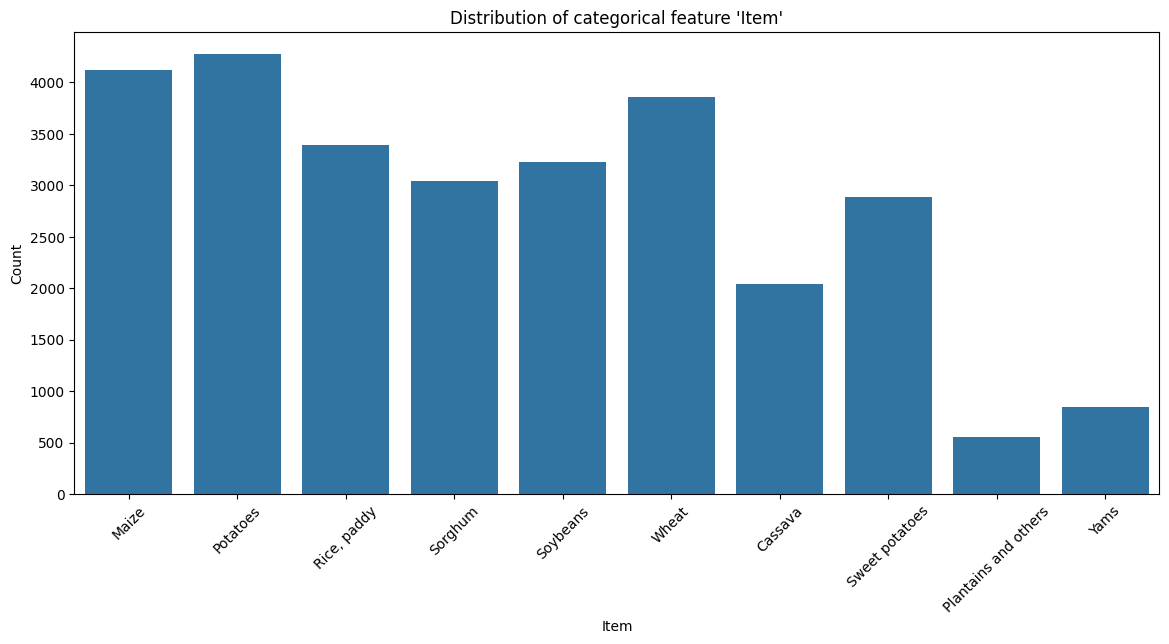

In [42]:
from src.univariate_analysis import NumericalUnivariateAnalyzer, CategoricalUnivariateAnalyzer, uni_analyzer
# Numerical columns are year, average rainfall, crop yields, pesticide in tonnes, and avg_temp
univariate_analyzer= uni_analyzer(NumericalUnivariateAnalyzer())
univariate_analyzer.execute_analysis(df,'Year')
univariate_analyzer.execute_analysis(df,'average_rain_fall_mm_per_year')
univariate_analyzer.execute_analysis(df,'crop_yields')
univariate_analyzer.execute_analysis(df,'pesticide_tonnes')
univariate_analyzer.execute_analysis(df,'avg_temp')


# categorical columns are area and Item,
univariate_analyzer= uni_analyzer(CategoricalUnivariateAnalyzer())
univariate_analyzer.execute_analysis(df,'Area')
univariate_analyzer.execute_analysis(df,'Item')

***Current Insights***
   
**Numerical Analysis**

- **Year:** The final dataset is from 1990 up until 2013.
While this does not possess much analytical value, we have a fair idea on how the data size was captured over time increasing steadily over the years, taking a major dip between 2002 and 2003, goes back to a steady pace, and dips again in towards the 2010s

- **Average rainfall:** As expected this is supposed to be all over the place. But it's clear that more of the data has an average rainfall of 1000mm (1 metre).

- **crop yields:** The crops in our dataset don't all come in large baskets apparently, more of them lie in the 0-100,000 range. barely any cross into the 500,000 range.

- **pesticide_tonnes:** The same goes for the pesticides used, A lot of the data lies in the 0-50,000 range, very few get past 100,000. But this could be a good thing, perhaps very few locations had to use a lot of pesticides.

- **average temperature:** There is an even spread of  locations with similar average temperatures, most locations had higher temps, very few were working with lower temps.





**Categorical Analysis**
- **Area:** A 101 countries were collated, with India having the highest frequency, appearing over 4,000 times in the dataset.

- **Item:** The highest crop collated is Potatoes, appearing 4,276 times, and the least is Plantains and others, appearing only 500 times. 

***NB:*** I would need to compare Item (crops) against Area (locations), to better understand which country contributed to the yield of these crops.

**Bivariate Analysis**

In [43]:
from src.bivariate_analysis import Numerical_vs_Numerical_Analyzer, Numerical_vs_Categorical_Analyzer, Categorical_vs_Categorical_Analyzer, bi_analyzer

In [44]:
df.columns

Index(['Area', 'Year', 'average_rain_fall_mm_per_year', 'Item', 'crop_yields',
       'pesticide_tonnes', 'avg_temp'],
      dtype='object')

In [45]:
bivariate_analyzer = bi_analyzer(Numerical_vs_Numerical_Analyzer())
# Numerical columns are year, average rainfall, crop yields, pesticides(in tonnes), and the average temperature

#Crop yields against pesticide use:
# bivariate_analyzer.execute_analysis(df,'crop_yields','pesticide_tonnes')

# crop yield against average temperature
# bivariate_analyzer.execute_analysis(df, 'crop_yields', 'avg_temp')

# crop yield against rainfall
# bivariate_analyzer.execute_analysis(df, 'average_rain_fall_mm_per_year', 'crop_yields')

# pesticide use vs average temp: Higher temps usually have more pest activity
# bivariate_analyzer.execute_analysis(df, 'avg_temp', 'pesticide_tonnes')


**Categorical data vs numerical data**

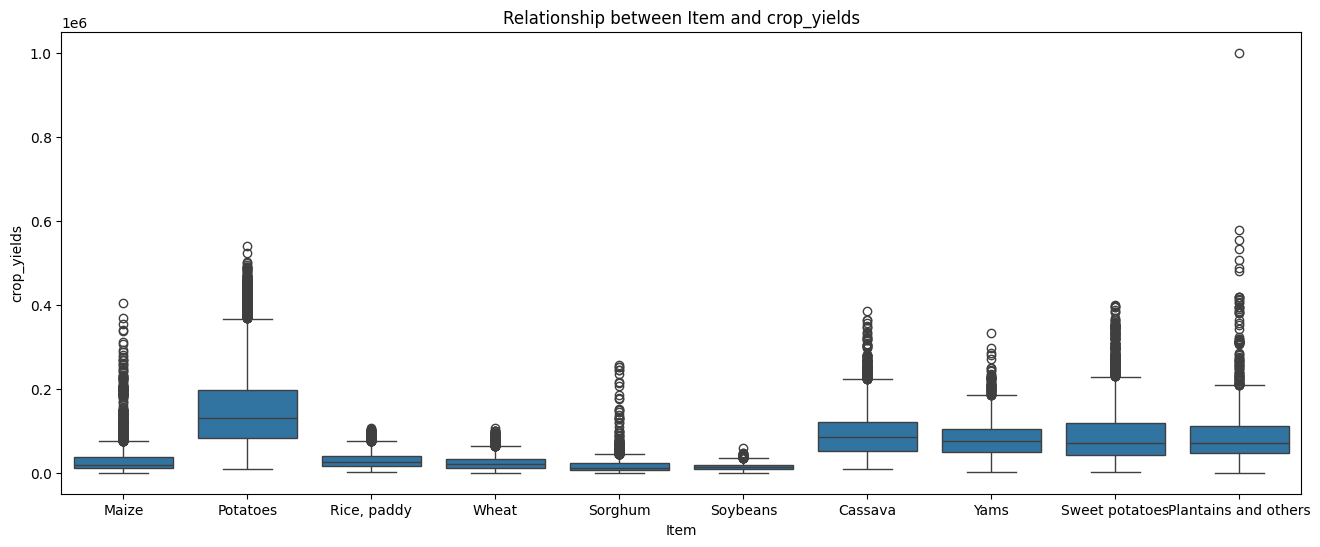

In [46]:
bivariate_analyzer.set_analyzer(Numerical_vs_Categorical_Analyzer())
bivariate_analyzer.execute_analysis(df_yield,"Item","crop_yields")

**Multivariate Analysis**


In [47]:
from src.multivariate_analysis import SimpleMultivariateAnalyzer, multi_analyzer

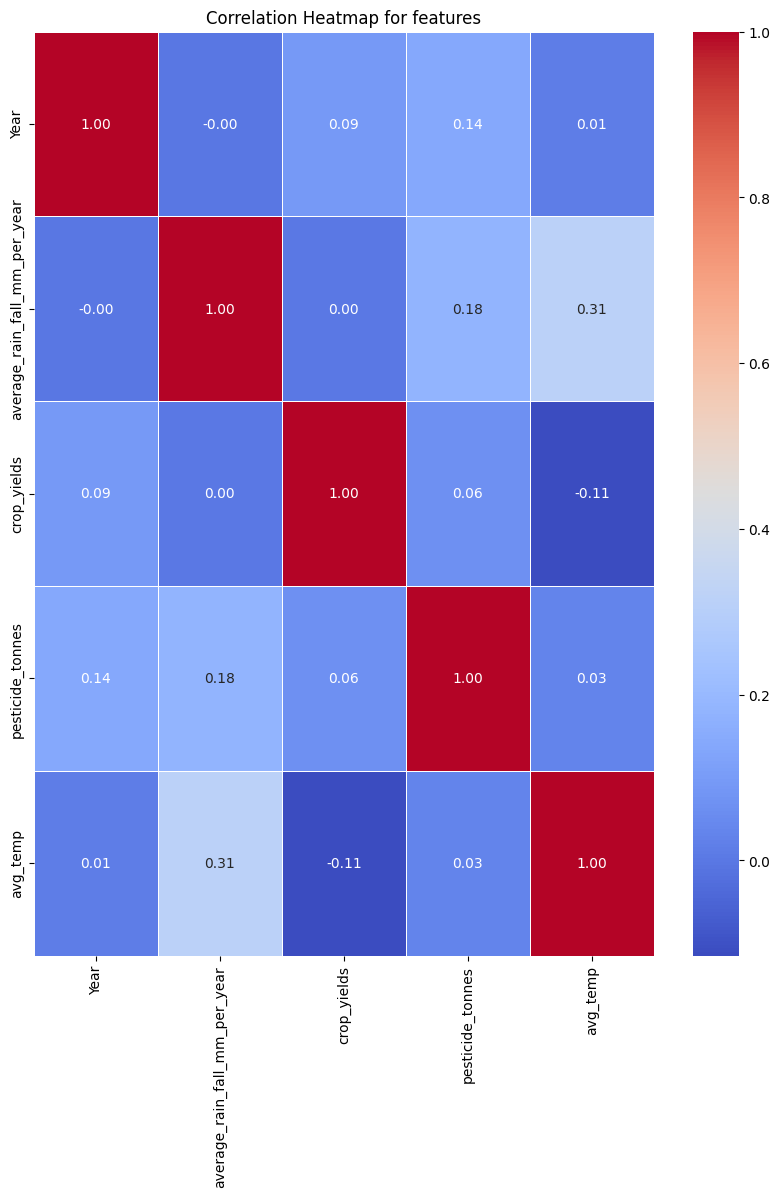

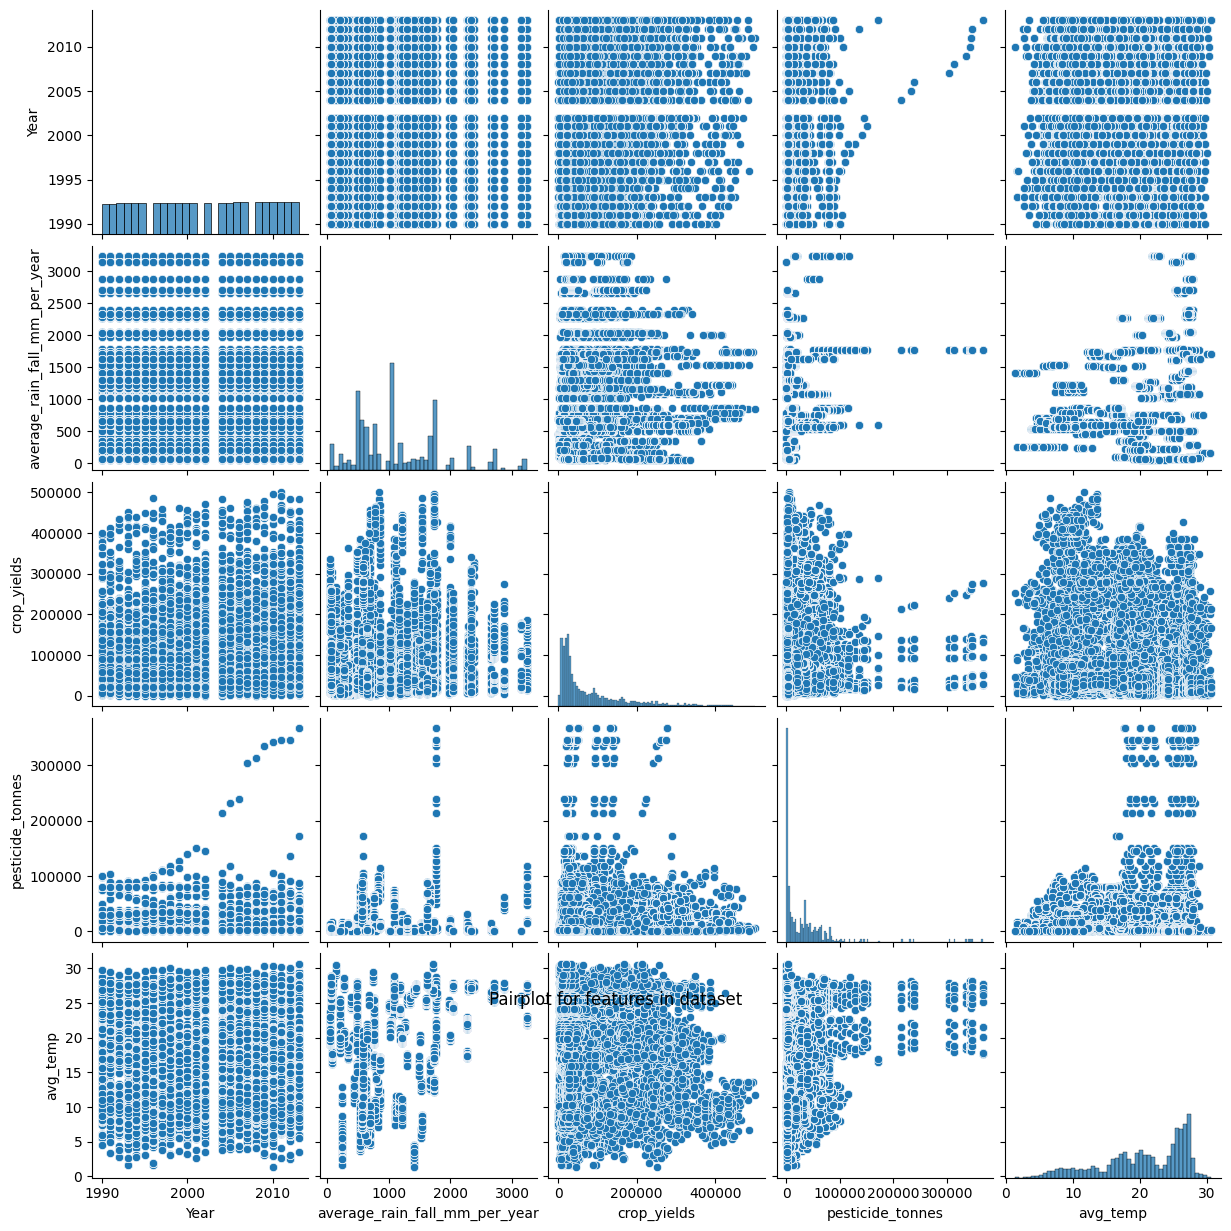

In [48]:
multivariate_analyzer = multi_analyzer(SimpleMultivariateAnalyzer())

important_datasets = df[['Year', 'average_rain_fall_mm_per_year', 'crop_yields',
       'pesticide_tonnes', 'avg_temp']]
    
multivariate_analyzer.execute_analysis(important_datasets,10,12)



**Current Insights**

**1. Pesticide usage increases past 200,000 in the years after 2000.**

 - The year vs pesticide_tonnes plot shows positive correlation at that point.

 - There were almost no high-pesticide values before 2000; after ~2005–2007 the scatter plot moves sharply upward and keeps climbing.

**2. Crop yields vs Pesticides**
In the crop_yield vs pesticide_tonnes plot, there is no stong positive cloud, but also almost no very high yield when over 100,000 tonnes of pesticide is applied.



**Targetted insights**

**Q. Which crops had the most crop yields, and in what location too?**

In [49]:
df.groupby('Item').count()

,Area,Year,average_rain_fall_mm_per_year,crop_yields,pesticide_tonnes,avg_temp
Item,,,,,,
Cassava,2045,2045,2045,2045,2045,2045
Maize,4121,4121,4121,4121,4121,4121
Plantains and others,556,556,556,556,556,556
Potatoes,4276,4276,4276,4276,4276,4276
"Rice, paddy",3388,3388,3388,3388,3388,3388
Sorghum,3039,3039,3039,3039,3039,3039
Soybeans,3223,3223,3223,3223,3223,3223
Sweet potatoes,2890,2890,2890,2890,2890,2890
Wheat,3857,3857,3857,3857,3857,3857


**A. Potatoes, maize and wheat have the largest crop produces**

Now to find out which countries contributed the most, we'll select the ten highest contributing countries.

In [50]:
from src.ranking_analysis import ranking_analyzer, Target_grouping_Ranking, Double_grouping_Ranking

In [51]:
rankings = ranking_analyzer(Target_grouping_Ranking())

c:\Users\mrtom\Documents\Courses\ML\Projects\50 ML Projects in 50 days\Crop yield predictor\EDA\src\ranking_analysis.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank, x=feature3, y="label", palette="viridis")


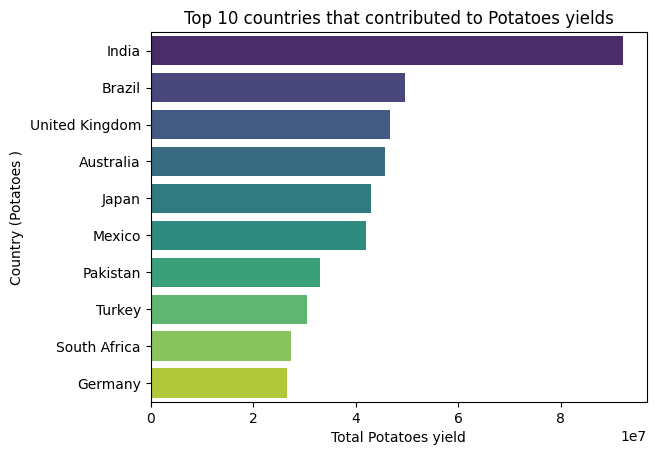

In [52]:
#  Potatoes
rankings.run(df, target = "Potatoes", feature1 = 'Item', feature2 ='Area', feature3 = 'crop_yields',title="Top 10 countries that contributed to Potatoes yields", xlabel = "Total Potatoes yield", ylabel = "Country (Potatoes )", filepath= "./charts/Potatoes_yield_chart.png")

**India is a major contributor to Potato yields recorded.**

c:\Users\mrtom\Documents\Courses\ML\Projects\50 ML Projects in 50 days\Crop yield predictor\EDA\src\ranking_analysis.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank, x=feature3, y="label", palette="viridis")


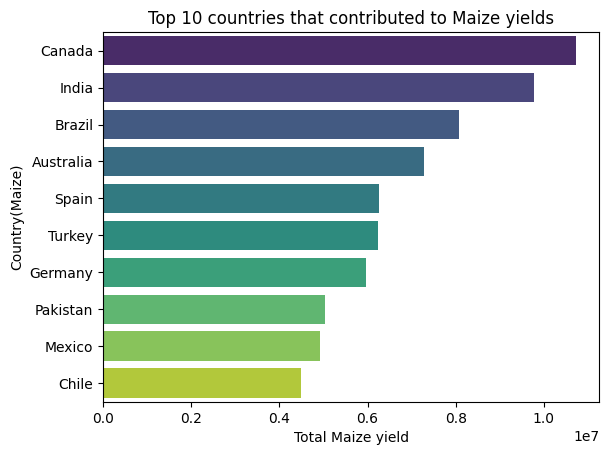

In [53]:
# Maize
rankings.run(df, target = "Maize", feature1 = 'Item', feature2 ='Area', feature3 = 'crop_yields',title="Top 10 countries that contributed to Maize yields", xlabel = "Total Maize yield", ylabel = "Country(Maize)", 
filepath= "./charts/Maize_yield_chart.png")

**Canada and India are the major contributors to Maize yields recorded**

c:\Users\mrtom\Documents\Courses\ML\Projects\50 ML Projects in 50 days\Crop yield predictor\EDA\src\ranking_analysis.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank, x=feature3, y="label", palette="viridis")


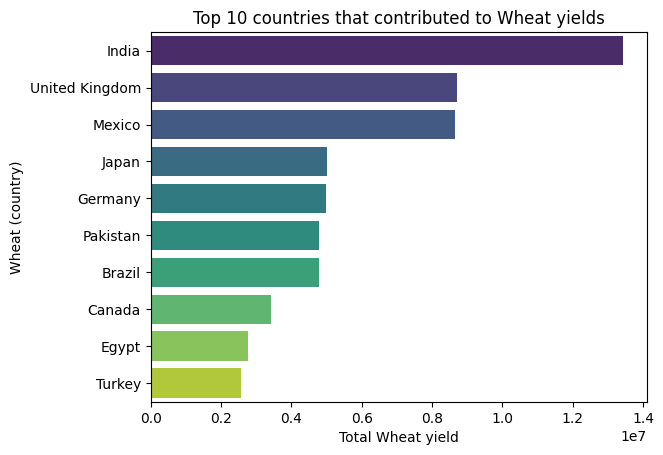

In [54]:
# # Wheat
rankings.run(df, target = "Wheat", feature1 = 'Item', feature2 ='Area', feature3 = 'crop_yields',title="Top 10 countries that contributed to Wheat yields", xlabel = "Total Wheat yield", ylabel = "Wheat (country)", filepath= "./charts/Wheat_yield_chart.png")

**Again, India is the major contributor, contributing over 1.3 million tonnes. of wheat.**

So, it's clear that India is a major producing country, it is ranking as number one currently. But, what did India produce the most of:

c:\Users\mrtom\Documents\Courses\ML\Projects\50 ML Projects in 50 days\Crop yield predictor\EDA\src\ranking_analysis.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank, x=feature3, y="label", palette="viridis")


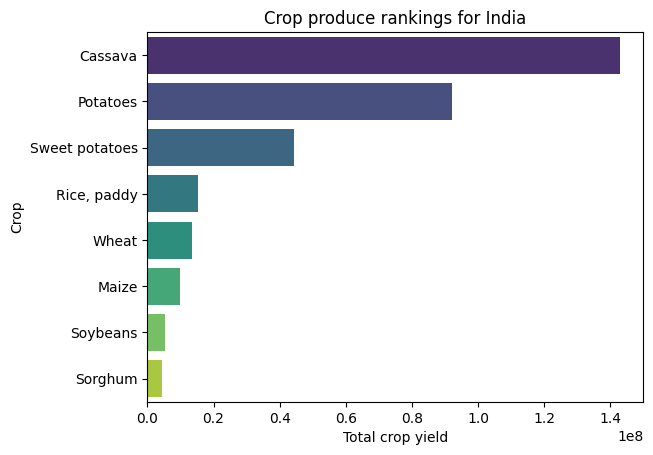

In [55]:
rankings.run(df, target = "India", feature1 = "Area",  feature2= "Item", feature3 = "crop_yields", title="Crop produce rankings for India", xlabel ="Total crop yield",ylabel= "Crop", filepath="./charts/India's_crops_rankings_chart")

Funny enough, it's Cassava. Not potatoes. Potatoes come in second, though.

**Q.** Which country had to apply the most pesticide

c:\Users\mrtom\Documents\Courses\ML\Projects\50 ML Projects in 50 days\Crop yield predictor\EDA\src\ranking_analysis.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank, x=feature3, y="label", palette="viridis")


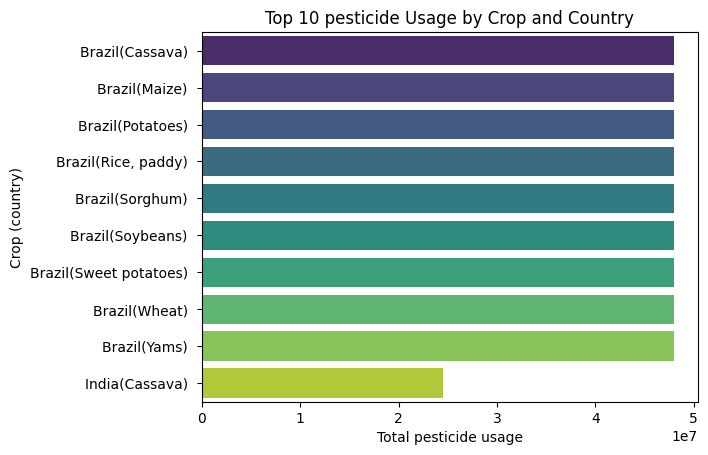

In [56]:
rankings.set_analyzer(Double_grouping_Ranking())

rankings.run(df, feature1 = "Item",  feature2= "Area", feature3 = "pesticide_tonnes", title="Top 10 pesticide Usage by Crop and Country", xlabel ="Total pesticide usage",ylabel= "Crop (country)", file_path="./charts/pesticide_usage_ for each crop and country_chart")

**Crop Cultivation Volume Insights**
Amongst the ten crops studied, Potatoes emerge as the most instensively cultivated crop, in terms of harvested areas and sheer production volume.
And India is the single largest contibutor to the global-potato cultivation during this 1990-2013 period.


**Pesticide Insights**

Brazil consistently ranks as the country with the highest total pesticide application across the studied crops.
It's safe to infer this pattern holds out when pesticide usage is aggregated by individual crop type, and when viewed across all crops combined.

But, I'm curious. What was the temperature like in Brazil over the years. I know that higher temperatures usually favour pest activities, I want to see if that has any relations here.

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
brazil = df[df['Area'].str.contains('Brazil', case=False)].copy()
brazil = brazil.sort_values('Year')

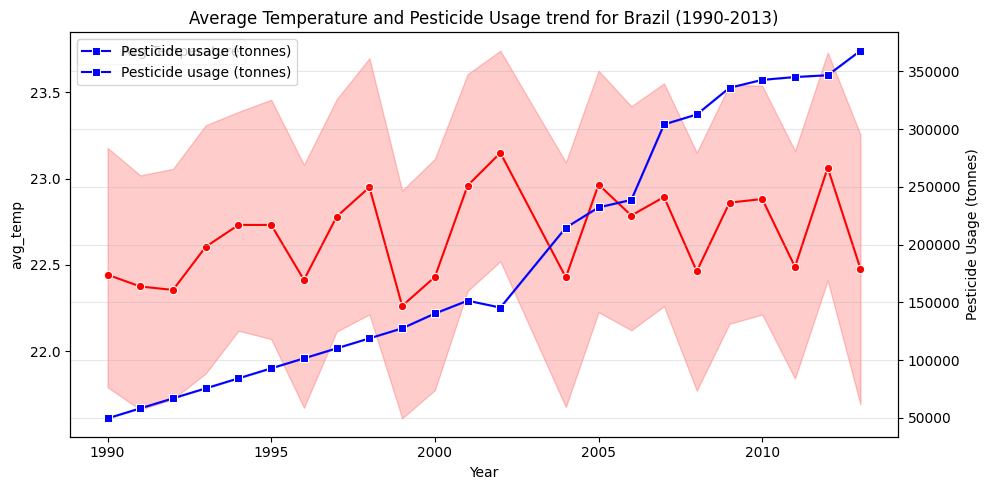

In [59]:
plt.figure(figsize=(10, 5))

# Main plot line: This one represents temperature
sns.lineplot(data=brazil, x='Year', y='avg_temp', marker='o', color='red', label='Avg Temperature')

# Secondary axis: This one would represent the average rainfall
ax2 = plt.gca().twinx()
sns.lineplot(data = brazil, x = 'Year', y = 'pesticide_tonnes', marker = 's', color = 'blue', label = 'Pesticide usage (tonnes)',ax = ax2)

plt.title("Average Temperature and Pesticide Usage trend for Brazil (1990-2013)")
plt.xlabel("Year")
plt.ylabel("Temperature")
ax2.set_ylabel("Pesticide Usage (tonnes)")

# Legends
lines1, labels1 = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [60]:
# Quick trend summary on the temperature and pesticide usage:
print("Temperature in Brazil (min/max/mean from 1990-2013): ")
print(brazil['avg_temp'].describe())

# Gets the mean of the the temperature data before 2000
early = brazil[brazil['Year']<= 2000]['avg_temp'].mean()

# Gets the mean of the the temperature data from 2005
late = brazil[brazil['Year'] >=2005]['avg_temp'].mean()


print(f"\nAverage temperature (1990-2000): {early:.2f}")
print(f"Average temperature (2005-2013): {late:.2f}")
print(f"Rough change in temperature: +{late-early:.2f} Celsius")


print("\n------------------------------------------------")
print("Pesticide Usage in Brazil (min/max/mean from 1990-2013): ")
print(brazil['pesticide_tonnes'].describe())

# Get the mean of the pesticide usage before the year 2000
early = brazil[brazil['Year']<= 2000]['pesticide_tonnes'].mean()

# Gets the mean of the the pesticide usage data from 2005
late = brazil[brazil['Year'] >=2005]['pesticide_tonnes'].mean()


print(f"\nAverage Pesticide Usage (1990-2000): {early:.2f}")
print(f"Average Pesticide usage (2005-2013): {late:.2f}")
print(f"Rough change in Pestcide Usage: +{late-early:.2f} tonnes")


Temperature in Brazil (min/max/mean from 1990-2013): 
count    2277.000000
mean       22.673913
std         3.504673
min        17.570000
25%        19.150000
50%        21.910000
75%        25.950000
max        28.760000
Name: avg_temp, dtype: float64

Average temperature (1990-2000): 22.55
Average temperature (2005-2013): 22.76
Rough change in temperature: +0.21 Celsius

------------------------------------------------
Pesticide Usage in Brazil (min/max/mean from 1990-2013): 
count      2277.000000
mean     189736.869565
std      108835.427440
min       49695.000000
25%       92967.220000
50%      145552.000000
75%      312637.000000
max      367778.000000
Name: pesticide_tonnes, dtype: float64

Average Pesticide Usage (1990-2000): 93347.55
Average Pesticide usage (2005-2013): 313925.00
Rough change in Pestcide Usage: +220577.45 tonnes



**Brazil's average temperature trend insighst:**

In Brazil, temperatures flunctuents between approx. 21.5 and 23.5 degrees,clearly showing typical inter-annual variability (peaks and dips of 0.5 or 1.5 degrees across the years).

While there is no strong consistent long term warming evident at a national level across the 24 years. The pattern can be deemed 'stable' with natural oscillations (most likely influenced by other climatic variablility).


**Brazil's pesticide usage trend insights:**
Total pesticide consumption shows a clear, and awfully scary upward trajectory, rising from roughly 50,000-70,000 tonnes in the early 1990s to over 350,000 tonnes by 2013. If my math is right, that's an increase of approximately 5-7 times over the period. The growth accelerates noticeably after 2000 through 2005, but becomes monotonic in the later years.



**Relationship between the temperature and pesticide usage**: Sad to say, but there's no correlation for the exact reasons I have stated above. The temperature in Brazil over the 24 year period(1990-2013) is relatively 'stable'. But our pesticide chart is obviously skewing and reacting, in ways that clearly has nothing to do with the temperature. 

**So why the trend moving like that?**

Looking at the dates, and after a quick google search, the surges aligns more closely with agricultural transfomations. Here's some that I found:

- A rapid expansion of export-oriented croplands in the Cerrado and other regions.

- Agricultural intensification.

- Wide spread adoption of genetically modified varieties (around the late 1950s)

- An increase in pest pressure, weed resistance, and reliance on chemical inputs

Now, I'm not going to downplay the role temperature has to play, it's definitely a factor, but according to this factor, it's more likely playing a secondary role.



## **Final Overall Summary of the analysis**

This fairly intensive exploratory data analysis provides a multi-dimensional view of yield performance for ten major staple crops between the years of 1990 and 2013, using FAO yield and pesticide usage records, with World Bank rainfall data and global temperature.


The following are my key findings:

- **Crop Importance rankings**: Potatoes, Maize and Wheat stand out as the most widely cultivated crop (by area and production size) amongst the ten selected staples, with India being a dominant global producer for Potatoes, and wheat.

- **Pesticide usage patterns**: Brazil exhibits an exceptionally high record for pesticide usage in virtually all the crops for our study. Suggesting either very large cultivatable areas, intensive production systems, or just very high reliance on chemical protection.

At a global level, the strongest temporal signal in the dataset is the sharp rise in pesticide usage starting in the early 2000s, a period where the crop yields showed more stability. Climates variables (rainafall, and temperature) showed minimal correlation with yield differences

------------------------------

Now that that's all done, let's save the final dataset.

But first, change up the column names.

In [ ]:
df = df.rename(index=str, columns={'Area': 'area','Year':'year','Item':'crops',})

In [ ]:
df.head()

In [ ]:
df.to_csv("../data/processed/Final_dataset.csv", index = False, sep =',',header = True)